Порог Отсу: 128.0
Кандидатов после фильтра по углу: 7
Длина самого длинного отрезка: 238.9
Суммарная длина коллинеарных: 476.4


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

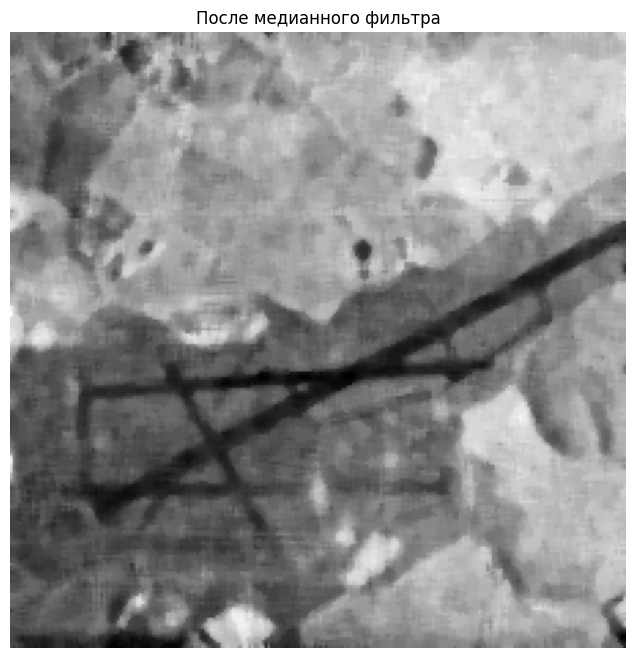

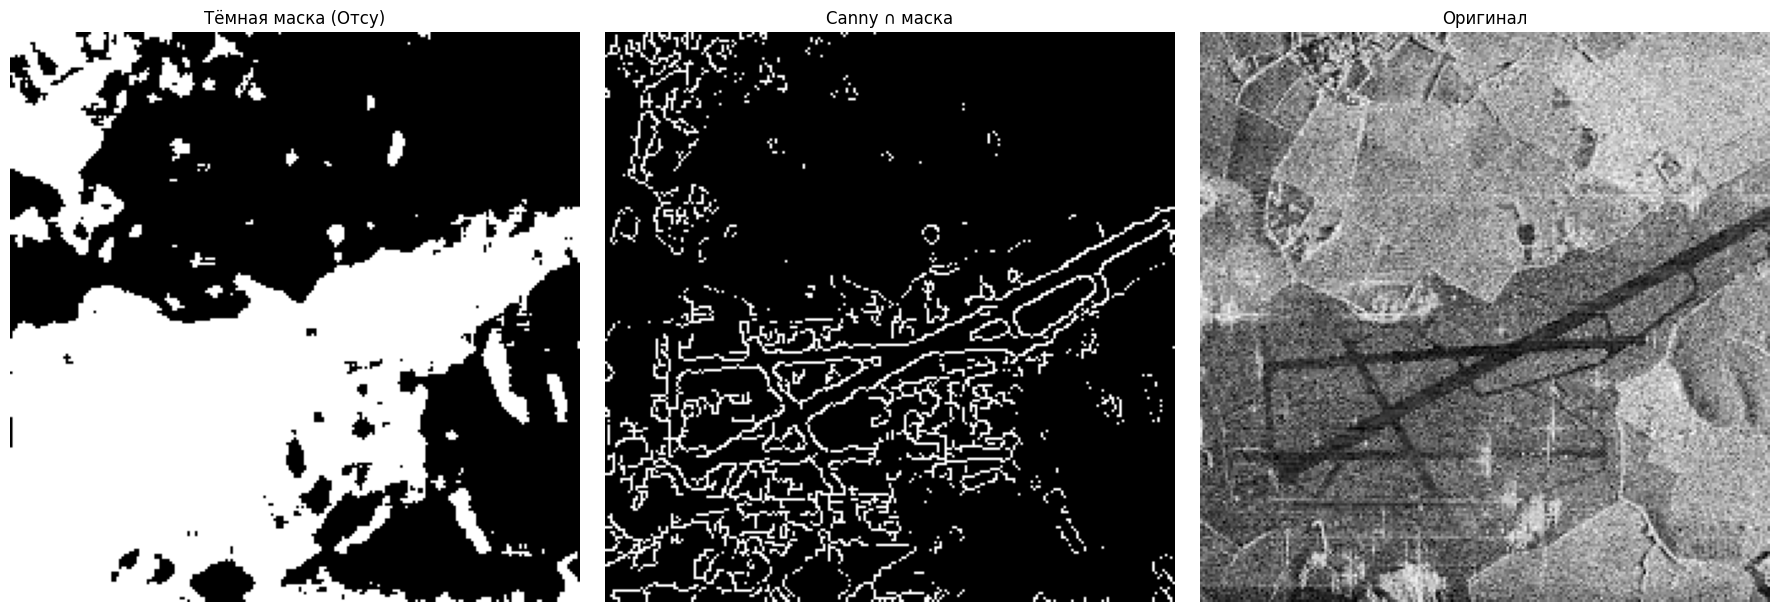

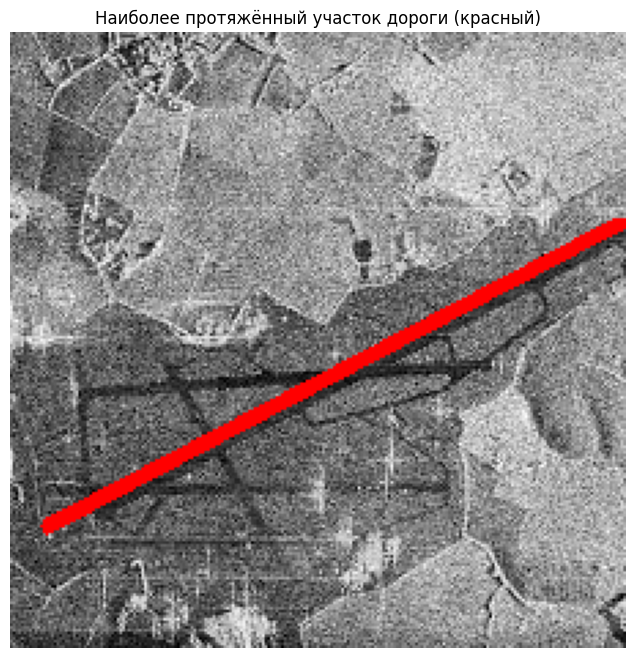

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_blur = cv2.medianBlur(image_gray, 5)

plt.figure(figsize=(8, 8))
plt.imshow(image_blur, cmap='gray')
plt.title('После медианного фильтра')
plt.axis('off')

thr_val, dark_mask = cv2.threshold(
    image_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
print('Порог Отсу:', thr_val)


canny = cv2.Canny(image_blur, 40, 120, apertureSize=3)
canny = cv2.bitwise_and(canny, dark_mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(dark_mask, cmap='gray'); axes[0].set_title('Тёмная маска (Отсу)'); axes[0].axis('off')
axes[1].imshow(canny, cmap='gray');     axes[1].set_title('Canny ∩ маска');        axes[1].axis('off')
axes[2].imshow(image_gray, cmap='gray'); axes[2].set_title('Оригинал');            axes[2].axis('off')
plt.tight_layout()
linesP = cv2.HoughLinesP(
    canny, rho=1, theta=np.pi / 180,
    threshold=60, minLineLength=80, maxLineGap=20
)

image_lines = image.copy()
candidates = []

if linesP is not None:
    linesP = linesP.reshape(-1, 4)
    for x1, y1, x2, y2 in linesP:
        length = math.hypot(x2 - x1, y2 - y1)
        angle = abs(math.degrees(math.atan2(y2 - y1, x2 - x1)))
        angle = min(angle, 180 - angle)
        if 15 <= angle <= 55:
            candidates.append((length, x1, y1, x2, y2))
            cv2.line(image_lines, (x1, y1), (x2, y2), (0, 255, 0), 1, cv2.LINE_AA)

print(f'Кандидатов после фильтра по углу: {len(candidates)}')
candidates.sort(reverse=True, key=lambda t: t[0])

longest = None
if candidates:
    longest = candidates[0]

def line_params(x1, y1, x2, y2):
    a = y2 - y1
    b = x1 - x2
    c = x2 * y1 - x1 * y2
    n = math.hypot(a, b)
    return a / n, b / n, c / n

def point_line_dist(px, py, a, b, c):
    return abs(a * px + b * py + c)

merged_mask = np.zeros_like(image_gray)
total_length = 0

if longest is not None:
    L, X1, Y1, X2, Y2 = longest
    a, b, c = line_params(X1, Y1, X2, Y2)
    for length, x1, y1, x2, y2 in candidates:
        d1 = point_line_dist(x1, y1, a, b, c)
        d2 = point_line_dist(x2, y2, a, b, c)
        if d1 < 5 and d2 < 5:
            cv2.line(merged_mask, (x1, y1), (x2, y2), 255, 3, cv2.LINE_AA)
            total_length += length

print(f'Длина самого длинного отрезка: {L:.1f}')
print(f'Суммарная длина коллинеарных: {total_length:.1f}')

result = image.copy()
result[merged_mask == 255] = (0, 0, 255)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Наиболее протяжённый участок дороги (красный)')
plt.axis('off')

Порог, найденный методом Отсу: 129.0
Компонента дорожной полосы: label=1, вытянутость=1.00


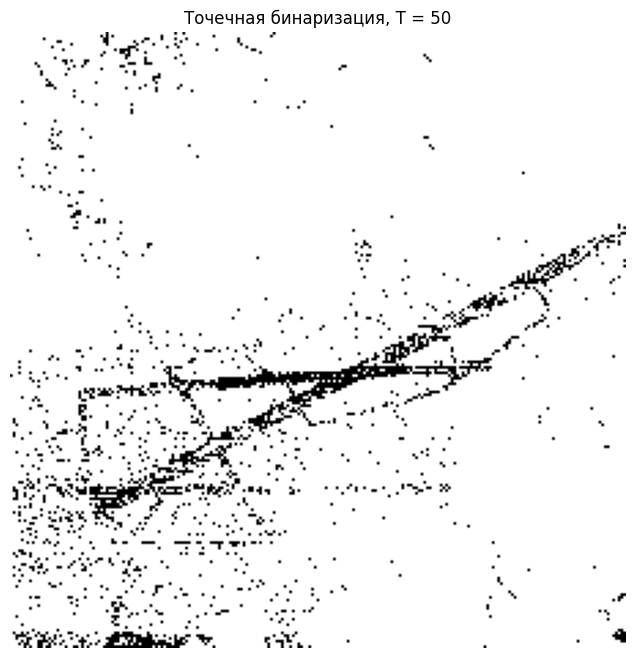

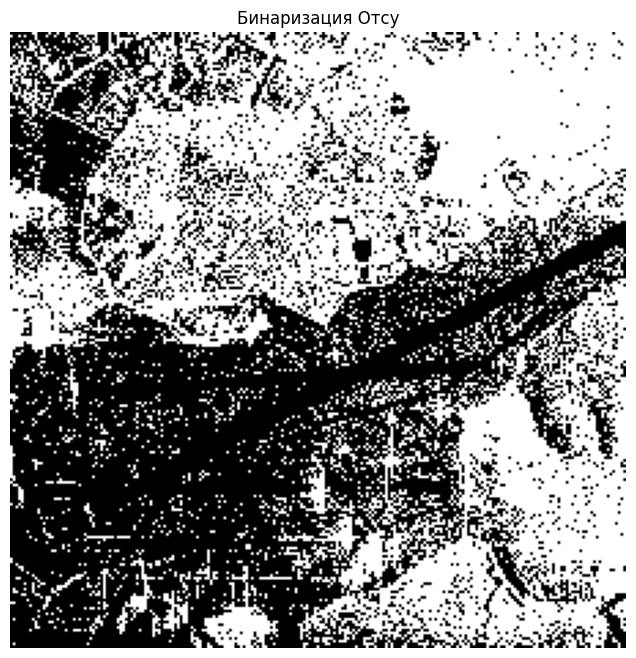

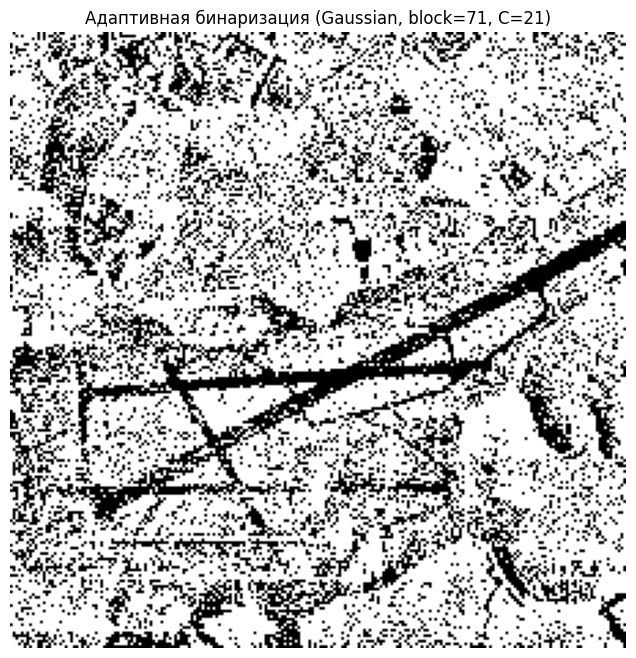

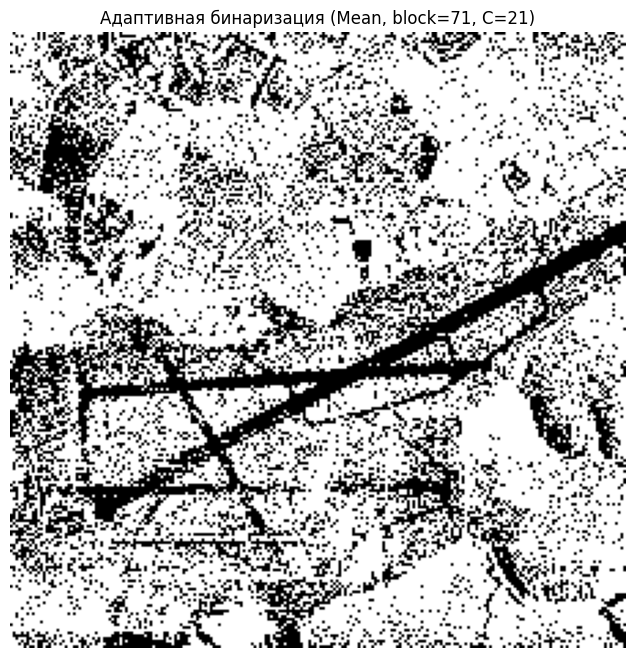

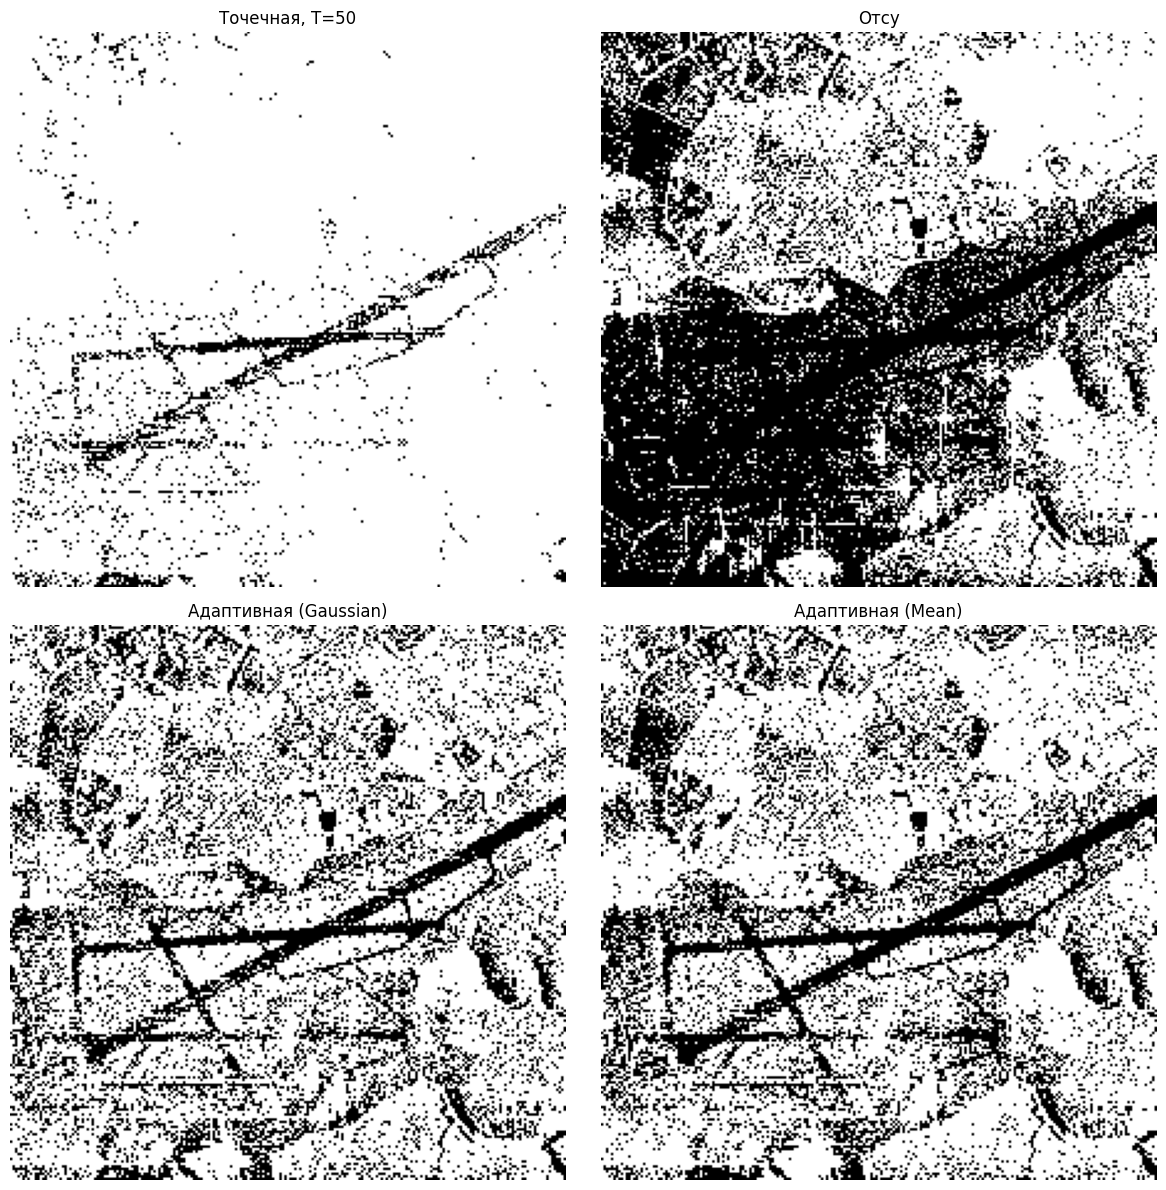

In [2]:

# Задание 2

import copy

bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.figure(figsize=(8, 8))
plt.imshow(bin_img, cmap='gray')
plt.title(f'Точечная бинаризация, T = {T}')
plt.axis('off')

_, th_otsu = cv2.threshold(
    image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print('Порог, найденный методом Отсу:', _)

plt.figure(figsize=(8, 8))
plt.imshow(th_otsu, cmap='gray')
plt.title('Бинаризация Отсу')
plt.axis('off')

th_adapt = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    71, 21
)

plt.figure(figsize=(8, 8))
plt.imshow(th_adapt, cmap='gray')
plt.title('Адаптивная бинаризация (Gaussian, block=71, C=21)')
plt.axis('off')

th_adapt_mean = cv2.adaptiveThreshold(
    image_gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    71, 21
)

plt.figure(figsize=(8, 8))
plt.imshow(th_adapt_mean, cmap='gray')
plt.title('Адаптивная бинаризация (Mean, block=71, C=21)')
plt.axis('off')

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(bin_img, cmap='gray')
axes[0, 0].set_title(f'Точечная, T={T}')
axes[0, 0].axis('off')

axes[0, 1].imshow(th_otsu, cmap='gray')
axes[0, 1].set_title('Отсу')
axes[0, 1].axis('off')

axes[1, 0].imshow(th_adapt, cmap='gray')
axes[1, 0].set_title('Адаптивная (Gaussian)')
axes[1, 0].axis('off')

axes[1, 1].imshow(th_adapt_mean, cmap='gray')
axes[1, 1].set_title('Адаптивная (Mean)')
axes[1, 1].axis('off')

plt.tight_layout()


road = th_otsu.copy()

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
road = cv2.morphologyEx(road, cv2.MORPH_CLOSE, kernel)
road = cv2.morphologyEx(road, cv2.MORPH_OPEN, kernel)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    road, connectivity=8
)

best_label = -1
best_elongation = 0

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]
    if area < 500:
        continue
    elongation = max(w, h) / (min(w, h) + 1e-6)
    if elongation > best_elongation:
        best_elongation = elongation
        best_label = i

print(f'Компонента дорожной полосы: label={best_label}, '
      f'вытянутость={best_elongation:.2f}')


